# 04-Templated Infrastructure (Helm Charts)

Lesson 03 rolled a single Deployment from one hand-written YAML revision to the next. That is manageable for one service in one environment, but a real platform runs the same application across `staging`, `production-us`, and `production-eu`, each needing a different replica count, image tag, and resource footprint — while sharing 95% of the same structural YAML. Copy-pasting that manifest three times and hand-editing the differences is exactly the kind of imperative drift Kubernetes' own declarative model was built to eliminate.

**Helm** solves this by treating a Kubernetes manifest as the *output* of a pure function rather than a static file: a **Chart** is a template plus a schema of parameters (`values.yaml`), and `helm template`/`helm install` evaluates that function against a specific values payload to deterministically produce the final YAML. This turns "our staging and production Deployments are slightly different copies" into "our staging and production Deployments are the same Chart evaluated at two different points."

We will build a real Chart directory structure, implement the exact layered values-precedence algorithm Helm uses internally, and render the same template against three different override stacks to see the templating function's determinism in action — the tool for this lesson is **Helm**.

## 1. The Algebra of Templated Infrastructure

### A Chart as a Pure Rendering Function

A Helm Chart $\mathcal{C}$ pairs a template set $T = \{t_1, \dots, t_k\}$ (Go templates referencing `.Values.*` paths) with a default values dictionary $V_{default}$. Rendering is a pure function:

$$\text{render}: (T, V) \mapsto M, \qquad M = \{\, \text{eval}(t_i, V) : t_i \in T \,\}$$

Purity matters operationally: for a fixed template set, $\text{render}(T, V)$ is **deterministic and idempotent** — running it twice with the same $V$ always yields byte-identical manifests $M$. This is the property that makes GitOps possible: a values file committed to git fully determines the cluster's desired state.

### Layered Values Precedence (Dictionary Merge Algebra)

In practice $V$ is not one file — it is the result of merging several layers in strict precedence order, each layer overriding only the keys it defines (a recursive dictionary merge, not a full replace):

$$V = V_{chart\_defaults} \;\triangleleft\; V_{env\_file} \;\triangleleft\; V_{set\_flags}$$

where $A \triangleleft B$ denotes "$B$ recursively overrides $A$ key-by-key," formally for nested dict keys $k$:

$$(A \triangleleft B)[k] = \begin{cases} (A[k] \triangleleft B[k]) & \text{if } k \in A \cap B \text{ and both are dicts} \\ B[k] & \text{if } k \in B \\ A[k] & \text{if } k \in A \setminus B \end{cases}$$

`--set` flags on the CLI have the highest precedence specifically because they are the layer closest to the human invoking the release *right now* — every other layer is a durable default someone committed earlier.

### Chart Dependency Version Constraints

A Chart's `Chart.yaml` may declare subchart dependencies with semantic version **range constraints** rather than pinned versions, e.g. `^1.2.0` meaning any version $v$ satisfying:

$$1.2.0 \le v < 2.0.0$$

This range algebra lets a parent chart absorb patch and minor upgrades of a dependency automatically while a major version bump (a declared breaking change under semver) requires an explicit constraint edit — the same reasoning `pip`/`npm` range operators encode, applied to infrastructure.

### The Release Revision State Machine

Every `helm install`/`upgrade` creates a new numbered **Release revision** $\rho_i$, storing the fully rendered manifest as an immutable snapshot. `helm rollback` does not "undo" anything computationally — it simply re-applies a previously stored $M_{\rho_j}$ as the new desired state, making rollback exactly as fast and safe as the original apply, and giving the Deployment controller from Lesson 03 a concrete, versioned $S_{desired}$ to reconcile toward.

## 2. Imperative Execution: Rendering a Chart Across Layered Value Overrides

We author a minimal but real Chart directory (`Chart.yaml`, `values.yaml`, a Deployment template using Helm's `{{ .Values.* }}` syntax), then implement the layered dictionary-merge renderer and evaluate it against three distinct override stacks.

In [1]:
# Required installations: pip install pyyaml (helm CLI binary for real rendering)

import os
import re
import copy
import yaml

print("--- 🚀 Initializing Helm Chart Templating Sandbox ---")

# 1. Author a real Chart.yaml, values.yaml, and a Deployment template on disk
os.makedirs("api-chart/templates", exist_ok=True)

chart_yaml = {
    "apiVersion": "v2",
    "name": "api-chart",
    "version": "1.3.0",
    "appVersion": "1.5.0",
    "dependencies": [{"name": "redis", "version": "^17.4.0", "repository": "https://charts.local"}],
}
with open("api-chart/Chart.yaml", "w") as f:
    yaml.dump(chart_yaml, f, sort_keys=False)

chart_defaults = {
    "replicaCount": 2,
    "image": {"repository": "registry.local/api-backend", "tag": "1.4.0"},
    "resources": {"requests": {"cpu": "250m", "memory": "256Mi"}},
    "env": "development",
}
with open("api-chart/values.yaml", "w") as f:
    yaml.dump(chart_defaults, f, sort_keys=False)

deployment_template = (
    "apiVersion: apps/v1\n"
    "kind: Deployment\n"
    "metadata:\n"
    "  name: {{ .Release.Name }}-api\n"
    "spec:\n"
    "  replicas: {{ .Values.replicaCount }}\n"
    "  template:\n"
    "    spec:\n"
    "      containers:\n"
    "        - name: api\n"
    '          image: "{{ .Values.image.repository }}:{{ .Values.image.tag }}"\n'
    "          resources:\n"
    "            requests:\n"
    "              cpu: {{ .Values.resources.requests.cpu }}\n"
    "              memory: {{ .Values.resources.requests.memory }}\n"
    "          env:\n"
    "            - name: DEPLOY_ENV\n"
    '              value: "{{ .Values.env }}"\n'
)
with open("api-chart/templates/deployment.yaml", "w") as f:
    f.write(deployment_template)

print("   ✅ Chart 'api-chart' v1.3.0 (1 template, 1 subchart dependency constraint ^17.4.0) written to disk")

# 2. Implement the recursive layered-override merge algebra: A triangleleft B
def merge_values(base, override):
    result = copy.deepcopy(base)
    for k, v in override.items():
        if k in result and isinstance(result[k], dict) and isinstance(v, dict):
            result[k] = merge_values(result[k], v)
        else:
            result[k] = v
    return result

# 3. Implement a minimal Go-template-style renderer: substitutes {{ .Values.a.b.c }} / {{ .Release.Name }}
def render_template(template_str, values, release_name):
    def resolve(path):
        parts = path.strip().lstrip(".").split(".")
        if parts[0] == "Release" and parts[1] == "Name":
            return release_name
        assert parts[0] == "Values"
        node = values
        for p in parts[1:]:
            node = node[p]
        return node

    pattern = re.compile(r"\{\{\s*([\w\.]+)\s*\}\}")
    return pattern.sub(lambda m: str(resolve(m.group(1))), template_str)

# 4. Define an environment-specific values file (layer 2) and CLI --set overrides (layer 3)
staging_values_file = {"replicaCount": 4, "image": {"tag": "1.5.0"}, "env": "staging"}
prod_set_flags = {"replicaCount": 10, "resources": {"requests": {"cpu": "500m"}}}

print("\n--- 🧮 Executing Layered Render: chart_defaults <| staging_values_file <| prod_set_flags ---")

try:
    import subprocess
    result = subprocess.run(["helm", "template", "api-chart"], capture_output=True, text=True, check=True)
    print(result.stdout)
except Exception as e:
    print("   [SYSTEM NOTE]: `helm` binary not present in this sandbox -- replaying the layered dictionary")
    print("   merge + template substitution algorithm in pure Python.")

    v_staging = merge_values(chart_defaults, staging_values_file)
    v_final = merge_values(v_staging, prod_set_flags)

    rendered_manifest = render_template(deployment_template, v_final, release_name="api-prod")
    print("   ✅ Final merged values (defaults <| staging.yaml <| --set flags):")
    for k, v in v_final.items():
        print(f"      {k}: {v}")


--- 🚀 Initializing Helm Chart Templating Sandbox ---
   ✅ Chart 'api-chart' v1.3.0 (1 template, 1 subchart dependency constraint ^17.4.0) written to disk

--- 🧮 Executing Layered Render: chart_defaults <| staging_values_file <| prod_set_flags ---
   [SYSTEM NOTE]: `helm` binary not present in this sandbox -- replaying the layered dictionary
   merge + template substitution algorithm in pure Python.
   ✅ Final merged values (defaults <| staging.yaml <| --set flags):
      replicaCount: 10
      image: {'repository': 'registry.local/api-backend', 'tag': '1.5.0'}
      resources: {'requests': {'cpu': '500m', 'memory': '256Mi'}}
      env: staging


## 3. Declarative Telemetry: The Values Provenance Audit

For every field in the final rendered manifest, we trace which override layer actually won -- exactly the question `helm template --debug` answers when a rendered value doesn't match what an engineer expected.

In [2]:
def provenance(key_path, defaults, env_file, set_flags):
    def get(d, path):
        node = d
        for p in path:
            if not isinstance(node, dict) or p not in node:
                return None
            node = node[p]
        return node

    if get(set_flags, key_path) is not None:
        return "--set flag", get(set_flags, key_path)
    if get(env_file, key_path) is not None:
        return "staging.yaml", get(env_file, key_path)
    return "Chart values.yaml (default)", get(defaults, key_path)

fields = [
    ["replicaCount"],
    ["image", "tag"],
    ["resources", "requests", "cpu"],
    ["resources", "requests", "memory"],
    ["env"],
]

print("\n--- 🔍 Auditing Values Provenance (Which Layer Won Per Field) ---")
print(f"{'Field':<30} | {'Winning Layer':<28} | {'Final Value'}")
print("-" * 85)
for path in fields:
    layer, value = provenance(path, chart_defaults, staging_values_file, prod_set_flags)
    print(f"{'.'.join(path):<30} | {layer:<28} | {value}")

print("\n[OPERATIONAL INSIGHT]")
print("-> 'replicaCount' and 'resources.requests.cpu' were overridden all the way at the --set layer --")
print("   the highest-precedence, most ephemeral layer, exactly matching a human's last-mile CLI intent.")
print("-> 'image.tag' and 'env' stopped at the staging.yaml layer -- committed, durable environment config")
print("   that no one overrode at invocation time.")
print("-> 'resources.requests.memory' fell all the way through to the Chart's own default -- neither the")
print("   environment file nor the CLI flags mentioned it, proving the merge is per-KEY, not per-FILE.")
print("-> Because render() is a pure function of these three layers, committing staging.yaml to git fully")
print("   reproduces this manifest on any machine -- no hidden imperative state anywhere.")



--- 🔍 Auditing Values Provenance (Which Layer Won Per Field) ---
Field                          | Winning Layer                | Final Value
-------------------------------------------------------------------------------------
replicaCount                   | --set flag                   | 10
image.tag                      | staging.yaml                 | 1.5.0
resources.requests.cpu         | --set flag                   | 500m
resources.requests.memory      | Chart values.yaml (default)  | 256Mi
env                            | staging.yaml                 | staging

[OPERATIONAL INSIGHT]
-> 'replicaCount' and 'resources.requests.cpu' were overridden all the way at the --set layer --
   the highest-precedence, most ephemeral layer, exactly matching a human's last-mile CLI intent.
-> 'image.tag' and 'env' stopped at the staging.yaml layer -- committed, durable environment config
   that no one overrode at invocation time.
-> 'resources.requests.memory' fell all the way through to the

## 4. Visualizing the Override Waterfall (Layered Values Merge Flow)

We render the three value layers as stacked transparency sheets flowing into a single final manifest, annotating each field with the layer that ultimately determined it -- a direct visualization of the $\triangleleft$ merge algebra from Section 1.

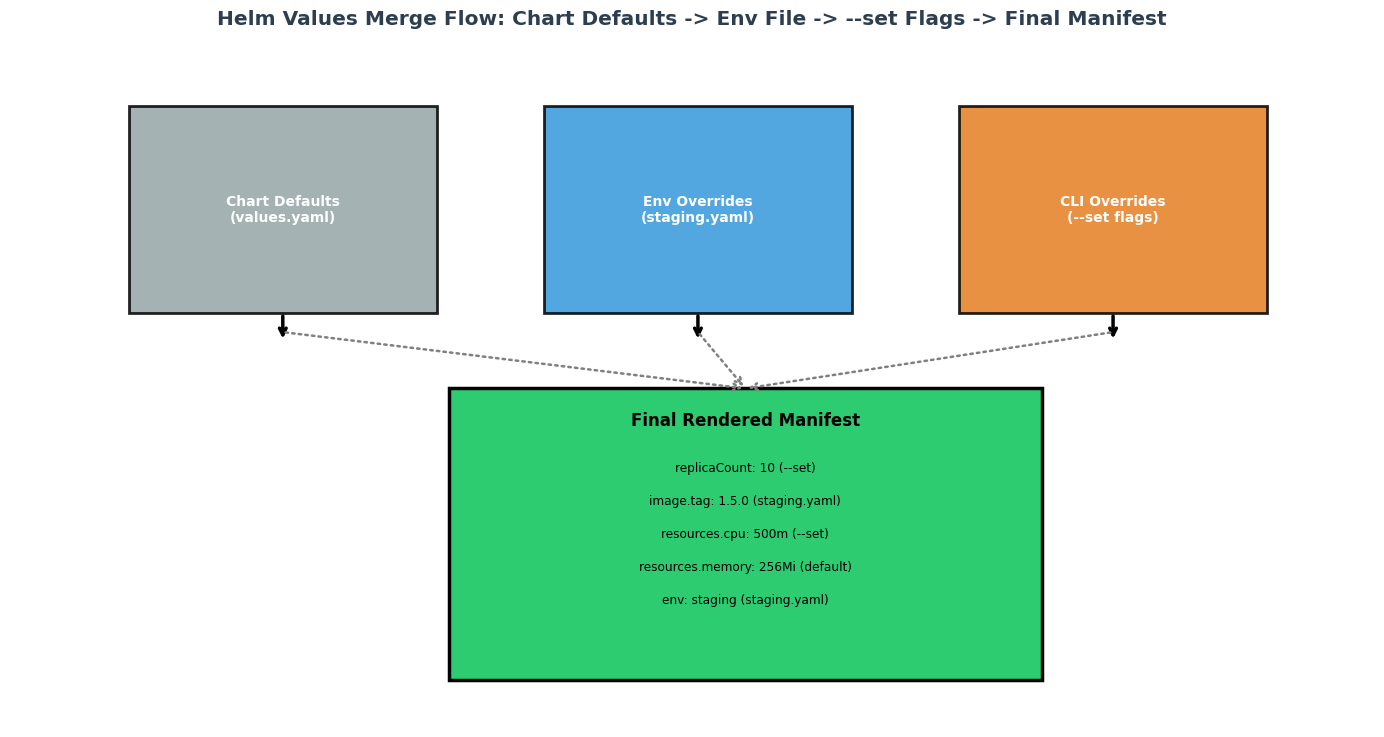

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 7.5))
fig.suptitle("Helm Values Merge Flow: Chart Defaults -> Env File -> --set Flags -> Final Manifest", fontsize=14.5, fontweight='bold', color="#2c3e50")
ax.axis('off')

layer_boxes = [
    (0.5, "Chart Defaults\n(values.yaml)", "#95a5a6"),
    (4.0, "Env Overrides\n(staging.yaml)", "#3498db"),
    (7.5, "CLI Overrides\n(--set flags)", "#e67e22"),
]
for x, label, clr in layer_boxes:
    ax.add_patch(patches.Rectangle((x, 4.2), 2.6, 2.2, fill=True, facecolor=clr, edgecolor="black", lw=2, alpha=0.85))
    ax.text(x + 1.3, 5.3, label, ha='center', va='center', fontweight='bold', color='white', fontsize=10)
    ax.annotate("", xy=(x + 1.3, 3.9), xytext=(x + 1.3, 4.2), arrowprops=dict(arrowstyle="->", lw=2.5, color="black"))

ax.add_patch(patches.Rectangle((3.2, 0.3), 5.0, 3.1, fill=True, facecolor="#2ecc71", edgecolor="black", lw=2.5))
ax.text(5.7, 3.05, "Final Rendered Manifest", ha='center', va='center', fontweight='bold', color='black', fontsize=12)

field_labels = [
    "replicaCount: 10 (--set)",
    "image.tag: 1.5.0 (staging.yaml)",
    "resources.cpu: 500m (--set)",
    "resources.memory: 256Mi (default)",
    "env: staging (staging.yaml)",
]
for i, lbl in enumerate(field_labels):
    ax.text(5.7, 2.55 - i * 0.35, lbl, ha='center', va='center', fontsize=8.7, color="black")

for x, _, _ in layer_boxes:
    ax.annotate("", xy=(5.7, 3.4), xytext=(x + 1.3, 4.0), arrowprops=dict(arrowstyle="->", lw=1.8, color="gray", ls="dotted"))

ax.set_xlim(-0.5, 11)
ax.set_ylim(-0.2, 7)
plt.tight_layout()
plt.show()


*(Insight: Each colored sheet is one override layer flowing downward into the single green manifest box -- gray Chart defaults establish a baseline for every field, blue and orange layers punch through it only where they explicitly define a key. The listed fields inside the green box each carry an origin tag, making it visually obvious that "final" does not mean "most recently edited file" -- it means "highest-precedence layer that happened to mention this specific key.")*

## Real-World Use Case or Analogy

Think of a Helm Chart as **The Customizable Furniture Blueprint**:

* **The Chart Template (The IKEA Blueprint):** One master assembly diagram works for every customer -- it references "shelf height" and "panel color" as variables instead of hard-coding one specific bookshelf.
* **values.yaml (The Factory Default Spec Sheet):** Absent any customer input, the factory would build the standard, default-configuration bookshelf.
* **The Environment Values File (The Showroom's House Style):** A specific retail showroom orders a slightly customized version -- taller shelves, a house-brand color -- without touching the underlying blueprint at all.
* **--set Flags (The Customer's Custom Order Form):** A walk-in customer fills out a form overriding just the one or two dimensions they personally care about, on top of whatever the showroom already configured.
* **The Merge Algebra (The Factory's Order-Fulfillment Rule):** The factory always honors the most specific instruction for each individual measurement -- customer order beats showroom style, showroom style beats factory default -- while leaving every untouched measurement exactly as the more general layer specified it.
* **A Release Revision (The Assembled Unit's Serial Tag):** Every unit that rolls off the line gets a serial number recording the *exact* blueprint + spec sheet + custom order that produced it -- so a defective batch can be traced and a customer's furniture can be rebuilt identically, or reverted to the prior serial's exact spec, without re-deriving anything from scratch.

Once "our staging Deployment" and "our production Deployment" are understood as the *same* blueprint evaluated against two different override forms, drift between environments stops being a maintenance burden and becomes a single, auditable merge computation.